## > run

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.metrics.cluster import adjusted_rand_score

## > run
Essas são as variáveis usadas para percorrer os timestamps:

- **minpts_max**: irá percorer de 2 até minpts -1, step 2 
- **local**: a pasta onde será salvo os resultados, é também o nome do dataset
- **ti**: imestamp inicial
- **tf**: timestamp final (acrescentar +1 por conta do FOR)

In [4]:
minpts_max = 201
local      = "covertype"
ti         = 200
tf         = 5801
skip       = []

## > run
Aqui é onde cria a pasta automaticamente, será criada uma pasta com o nome que é colocado na variável **local**

m_directory = os.path.join(os.getcwd(), "results_corestream_hastream/" + str(local))
        
try:
    if not os.path.exists(m_directory):
        os.makedirs(m_directory)
        
except FileNotFoundError as e:
    print(e)

## > run

Pega apenas a coluna do ARI (os ARIs de ralação de cada minpts) de cada timestamp e coloca nas variáveis com posição de 1 até o número de timestamps:
- **df_mean_std_corestream**
- **df_mean_std_hastream**

In [5]:
df_mean_std_corestream = pd.DataFrame(index=[x for x in range(2, 201, 2)])
df_mean_std_hastream   = pd.DataFrame(index=[x for x in range(2, 201, 2)])

for t in range(2600, tf, ti):
    if t in skip:
        continue
    try:
        df_max_ari_corestream          = pd.read_csv("corestream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)
        df_mean_std_corestream[t / ti] = df_max_ari_corestream['ARI']
    
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")

    try:
        df_max_ari_hastream            = pd.read_csv("hastream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)
        df_mean_std_hastream[t / ti] = df_max_ari_hastream['ARI']

        print(t)
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")

2600
2800
3000
3200
3400
3600
3800
4000
4200
4400
4600
4800
5000
5200
5400
5600
5800


## > run
Gera o cráfico com a média e desvio padrão dos timestamps do CoreStream (em azul) e Hastream (em amarelo).

O ARI é a comparação das partições do CoreStream com o HDBSCAN e o Hastream com o HDBSCAN.

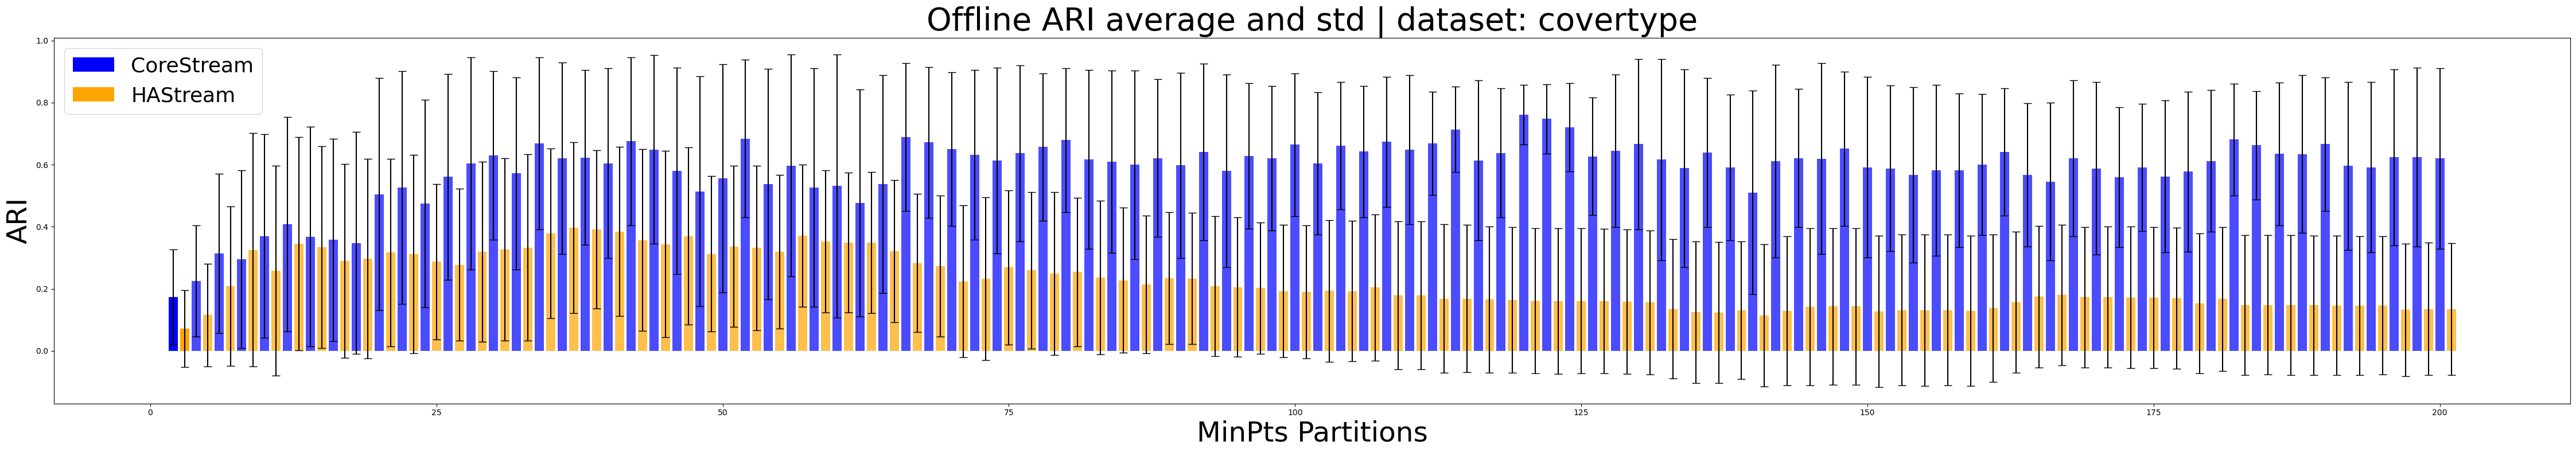

In [6]:
plt.figure(figsize = (45,8))
plt.title('Offline ARI average and std' + " | dataset: " + str(local), fontsize=40)

plt.bar(2, df_mean_std_corestream.mean(axis=1)[2], label='CoreStream', color="blue")
plt.bar(3, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="orange")
plt.xlabel("MinPts Partitions", fontsize=35)
plt.ylabel("ARI", fontsize=35)
    
for minpts in range(2, minpts_max, 2):
    plt.bar(minpts, df_mean_std_corestream.mean(axis=1)[minpts], yerr=df_mean_std_corestream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    plt.bar(minpts + 1, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="orange")
    
plt.legend(fontsize="26")

plt.tight_layout()

plt.savefig("results_corestream_hastream/" + str(local) + "_ari_mean_std_resume.png")

#plt.close()

fig, axs = plt.subplots(2, 1, figsize=(25, 15))

fig.suptitle('timestamps ARI average and std' + " | dataset: " + str(local), fontsize=30)

axs[0].bar(2, df_mean_std_corestream.mean(axis=1)[2], label='CoreStream', color="blue")
axs[0].bar(3, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="orange")
axs[0].set_xlabel("MinPts Partitions", fontsize=20)
axs[0].set_ylabel("ARI", fontsize=24)
    
for minpts in range(2, 101, 2):
    axs[0].bar(minpts, df_mean_std_corestream.mean(axis=1)[minpts], yerr=df_mean_std_corestream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    axs[0].bar(minpts + 1, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="orange")
    
axs[0].legend(fontsize="28")

axs[1].bar(102, df_mean_std_corestream.mean(axis=1)[2], label='CoreStream', color="blue")
axs[1].bar(103, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="orange")
axs[1].set_xlabel("MinPts Partitions", fontsize=20)
axs[1].set_ylabel("ARI", fontsize=24)

for minpts in range(102, 201, 2):
    axs[1].bar(minpts, df_mean_std_corestream.mean(axis=1)[minpts], yerr=df_mean_std_corestream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    axs[1].bar(minpts + 1, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="orange")

axs[1].legend(fontsize="28")

plt.tight_layout()
plt.show()

fig.savefig("results_corestream_hastream/" + local + "/ari_mean_std_resume.png")

#plt.close()

### ARI Partitions

for t in range(ti, tf, ti):
    #if t == 3300:
    #    continue
        
    df_ari_corestream = pd.read_csv("corestream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)

    df_ari_hastream = pd.read_csv("hastream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)

    plt.figure(figsize=(18, 8))
    plt.title("ARI t_" + str(t) + " | dataset: " + str(local), fontsize=26)
    plt.xlabel("MinPts Partitions", fontsize=24)
    plt.ylabel("ARI", fontsize=24)
    
    plt.bar(df_ari_corestream.index, df_ari_corestream['ARI'], color='blue', label='ARI CoreStream')
    plt.bar(df_ari_hastream.index + 1, df_ari_hastream['ARI'], color='orange', label='ARI HAStream')
    
    plt.legend()
    plt.savefig("results_corestream_hastream/" + local + "/ari_corestream_hastreamt" + str(t) + ".png")
    plt.close()

    print(t)

### MAX ARI

for t in range(ti, tf, ti):
    df_max_ari_corestream = pd.read_csv("corestream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", sep=',', index_col=0)

    df_max_ari_hastream = pd.read_csv("hastream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", sep=',', index_col=0)

    plt.figure(figsize=(18, 8))
    plt.title("Max ARI t_" + str(t) + " | dataset: " + str(local), fontsize=26)
    plt.xlabel("MinPts Partitions", fontsize=24)
    plt.ylabel("ARI", fontsize=24)
    plt.plot(df_max_ari_corestream.index, df_max_ari_corestream['Max_ARI'], marker='o', mec='r', mfc='r', color='b', label='ARI CoreStream')
    plt.plot(df_max_ari_hastream.index, df_max_ari_hastream['Max_ARI'], marker='o', mec='g', mfc='g', color='black', label='ARI HAStream')
    plt.legend()
    plt.savefig("results_corestream_hastream/" + local + "/max_ari_corestream_hastreamt" + str(t) + ".png")
    plt.close()

    print(t)

df_mean_std_corestream = pd.DataFrame(index=[x for x in range(2, 201, 2)], columns=range(1, 5))
df_mean_std_hastream   = pd.DataFrame(index=[x for x in range(2, 201, 2)], columns=range(1, 5))

for t in range(ti, tf, ti):
    df_max_ari_corestream = pd.read_csv("corestream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", sep=',', index_col=0)
    df_max_ari_hastream   = pd.read_csv("hastream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", sep=',', index_col=0)

    df_mean_std_corestream[t / ti] = df_max_ari_corestream['Max_ARI']
    df_mean_std_hastream[t / ti]   = df_max_ari_hastream['Max_ARI']
    
    print(t)

fig, axs = plt.subplots(2, 1, figsize=(25, 15))

fig.suptitle('timestamps MAX ARI average and std' + " | dataset: " + str(local), fontsize=30)

axs[0].bar(2, df_mean_std_corestream.mean(axis=1)[2], label='CoreStream', color="blue")
axs[0].bar(3, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="orange")
axs[0].set_xlabel("MinPts Partitions", fontsize=24)
axs[0].set_ylabel("ARI", fontsize=24)
    
for minpts in range(2, 101, 2):
    axs[0].bar(minpts, df_mean_std_corestream.mean(axis=1)[minpts], yerr=df_mean_std_corestream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    axs[0].bar(minpts + 1, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="orange")
    
axs[0].legend()

axs[1].bar(102, df_mean_std_corestream.mean(axis=1)[2], label='CoreStream', color="blue")
axs[1].bar(103, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="orange")
axs[1].set_xlabel("MinPts Partitions", fontsize=24)
axs[1].set_ylabel("ARI", fontsize=24)

for minpts in range(102, 201, 2):
    axs[1].bar(minpts, df_mean_std_corestream.mean(axis=1)[minpts], yerr=df_mean_std_corestream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    axs[1].bar(minpts + 1, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="orange")

axs[1].legend()

plt.tight_layout()
plt.show()

fig.savefig("results_corestream_hastream/" + local + "/max_ari_mean_std_resume.png")

#plt.close()